Importing the self-made decision tree and preparting the data

In [1]:
import pandas as pd
import numpy as np
from model_functions.Decision_Tree import Decision_Tree


train= pd.read_csv('claims_train.csv')
test = pd.read_csv('claims_test.csv')

#Cleaning weird values that found during cleaning
train = train[train['Exposure'] <= 1].copy()
test =test[test['Exposure']<=1].copy()

# Adding Risk column
train['Risk'] = train['ClaimNb'] / train['Exposure'] 
test['Risk'] =  test['ClaimNb'] / test['Exposure']

#Encoding
train_encoded=pd.get_dummies(train, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
train_encoded['Area']=train_encoded['Area'].map(area_map)

test_encoded=pd.get_dummies(test, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
test_encoded['Area']=test_encoded['Area'].map(area_map)

X_train=train_encoded.drop(columns=['ClaimNb','Exposure', 'IDpol','Risk'])
y_train=train['Risk']

X_test=test_encoded.drop(columns=['ClaimNb','Exposure', 'IDpol','Risk'])
y_test=test['Risk']

Building the tree

In [2]:

# #Train
our_tree=Decision_Tree(max_depth=6,min_samples_split=1000)
our_tree.fit(X_train.values,y_train.values)
#Print structure
our_tree.print_tree(our_tree.tree, feature_names=X_train.columns.tolist())

if VehAge <= 0:
  if VehGas_Regular <= False:
    if Region_R54 <= False:
      if VehPower <= 7:
        if VehPower <= 5:
          if VehBrand_B3 <= False:
            Predict Risk = 0.239
          else:
            Predict Risk = 1.259
        else:
          if VehBrand_B12 <= False:
            Predict Risk = 0.451
          else:
            Predict Risk = 1.331
      else:
        if VehPower <= 9:
          if DrivAge <= 25:
            Predict Risk = 0.672
          else:
            Predict Risk = 0.125
        else:
          if VehPower <= 10:
            Predict Risk = 1.654
          else:
            Predict Risk = 0.315
    else:
      Predict Risk = 2.427
  else:
    if VehBrand_B12 <= False:
      if Region_R25 <= False:
        if Density <= 8346:
          if Density <= 323:
            Predict Risk = 0.470
          else:
            Predict Risk = 0.171
        else:
          Predict Risk = 1.124
      else:
        Predict Risk = 3.878
    else:
      if VehPo

Using our tree for prediction

In [3]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
X_test=test_encoded.drop(columns=['ClaimNb','Exposure', 'IDpol','Risk'])
predictions = our_tree.predict(X_test.values)

mse=mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test,predictions)
r2 = r2_score(y_test, predictions)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")

MSE:  26.895058
RMSE: 5.186045
MAE:  0.492785
R²:   0.0088


The model is weak, want to check that the problem is not with my Tree code. Want to compare results with library version of the decision tree.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
sk_tree = DecisionTreeRegressor(max_depth=6,min_samples_split=1000,  random_state=42) #same set up
sk_tree.fit(X_train.values, y_train.values)
y_pred_sklearn = sk_tree.predict(X_test.values)

mse = mean_squared_error(y_test, y_pred_sklearn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_sklearn)
r2 = r2_score(y_test, y_pred_sklearn)

print(f"sklearn DecisionTreeRegressor results:")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")


sklearn DecisionTreeRegressor results:
MSE:  26.895058
RMSE: 5.186045
MAE:  0.492785
R²:   0.0088
0.35840464285833407


Ok, the sklearn tree is as bad as ours :D Then the problem is in a set up, need some other approach. Trying to do a classification of presense of Risk to get P(Risk>0) and then Regression on only nonzero-risk cases, then multiply probabilities.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Step 1: Classification (Risk > 0 or not) ---
y_class = (y_train > 0).astype(int)
clf = DecisionTreeClassifier(max_depth=6, min_samples_split=1000, random_state=42)
clf.fit(X_train.values, y_class)

# --- Step 2: Regression (only on nonzero-risk cases) ---
mask = y_train > 0
reg = DecisionTreeRegressor(max_depth=6, min_samples_split=500, random_state=42)
reg.fit(X_train.values[mask], y_train.values[mask])

# --- Step 3: Combine predictions ---
p_claim = clf.predict_proba(X_test.values)[:, 1]
expected_risk = reg.predict(X_test.values)
final_pred = p_claim * expected_risk

# --- Step 4: Evaluate combined model ---
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)
print(f"MAE: {mae:.4f}, R²: {r2:.4f}")


MAE: 0.4976, R²: 0.0070


This approach didn't help. Will try to add new categoric features based on bins in the exploration part.

In [ ]:
X_train['YoungDriver'] = (X_train['DrivAge'] < 25).astype(int)               #Adding age categories
X_train['MidAgeDriver'] = ((X_train['DrivAge'] >= 25) & (X_train['DrivAge'] < 60)).astype(int)
X_train['SeniorDriver'] = (X_train['DrivAge'] >= 60).astype(int)

X_test['YoungDriver'] = (X_test['DrivAge'] < 25).astype(int)               #Adding age categories
X_test['MidAgeDriver'] = ((X_test['DrivAge'] >= 25) & (X_test['DrivAge'] < 60)).astype(int)
X_test['SeniorDriver'] = (X_test['DrivAge'] >= 60).astype(int)

X_train['HighPower'] = (X_train['VehPower'] >= 7).astype(int)        #Adding High Power category
X_test['HighPower'] = (X_test['VehPower'] >=7).astype(int)

X_train['Brand12'] = (X_train['VehBrand_B12'] == True).astype(int)      #Brand b12 seems to be the most risky
X_test['Brand12'] = (X_test['VehBrand_B12'] == True).astype(int)

risky_regions=['R21','R43','R11']                                     #Top 3 most risky regions
X_train['Risky_region'] = train['Region'].isin(risky_regions).astype(int)
X_test['Risky_region']  = test['Region'].isin(risky_regions).astype(int)


X_train['UrbanArea'] = ((X_train['Area'] == 5) & (X_train['Area'] == 6)).astype(int)       #Urban areas are more risky
X_test['UrbanArea'] = ((X_test['Area'] == 5) & (X_test['Area'] == 6)).astype(int)

X_train['HighBonusMalus'] = (X_train['BonusMalus'] >200).astype(int)     #HighBonusMalus spikes risk
X_test['HighBonusMalus'] = (X_test['BonusMalus'] >200).astype(int)

X_train['MidDensity'] = ((X_train['Density'] >= 10000) & (X_train['Density'] < 15000)).astype(int) #Mid Density areas showed more risk
X_test['MidDensity']  = ((X_test['Density']  >= 10000) & (X_test['Density']  < 15000)).astype(int)



New features are added ,let's try the tree again

In [25]:
from sklearn.metrics import mean_poisson_deviance
sk_tree_new = DecisionTreeRegressor(max_depth=6,min_samples_split=1000,  random_state=42) # Changed set up a bit
sk_tree_new.fit(X_train.values, y_train.values)
y_pred_sklearn_new = sk_tree_new.predict(X_test.values)

mse = mean_squared_error(y_test, y_pred_sklearn_new)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_sklearn_new)
r2 = r2_score(y_test, y_pred_sklearn_new)

print(f"sklearn DecisionTreeRegressor results:")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")


sklearn DecisionTreeRegressor results:
MSE:  26.895058
RMSE: 5.186045
MAE:  0.492785
R²:   0.0088


Engineered features didn't help either. At this point we make a conclusion that maybe our evaluation metrics don't fit such imbalanced data. Instead from now on we are going to use mean poisson deviance

In [26]:
from sklearn.tree import  DecisionTreeRegressor
sk_tree_new = DecisionTreeRegressor(max_depth=6,min_samples_split=1000,  random_state=42) # Changed set up a bit
sk_tree_new.fit(X_train.values, y_train.values)
y_pred = sk_tree_new.predict(X_test.values)
y_pred_count= y_pred * test['Exposure']  # converting for evaluation using mean poisson deviance
y_true_count= test['ClaimNb']

from sklearn.metrics import mean_poisson_deviance
mpd_model = mean_poisson_deviance(y_true_count, y_pred_count)
print("Model Poisson Deviance:", mpd_model)


Model Poisson Deviance: 0.35840464285833407


 Now I will do a decile lift table

In [14]:
df=pd.DataFrame({'y_pred':y_pred_count, 'y_true':y_true_count})
df["decile"] = pd.qcut(df["y_pred"], 10, labels=False)
tab_tree=df.groupby("decile")["y_true"].mean()
print(tab_tree)

decile
0    0.016439
1    0.022372
2    0.030520
3    0.041906
4    0.045354
5    0.057657
6    0.051390
7    0.070286
8    0.085106
9    0.130477
Name: y_true, dtype: float64


In [15]:
overall_mean=y_true_count.mean()
lift_tree= tab_tree.iloc[-1]/ overall_mean
print(lift_tree)

2.427236630544572


Now we decided to do a classification view evaluation

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_true_bin= (y_true_count >0).astype(int)


precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred_count)
ap_tree = average_precision_score(y_true_bin, y_pred)

print(ap_tree)


0.08517387324065541


Time for some visualization

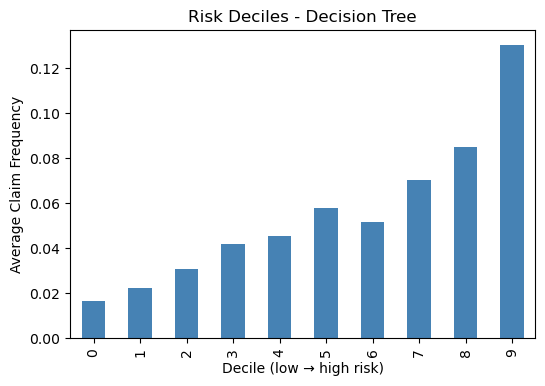

In [17]:
import matplotlib.pyplot as plt
def decile_plot(y_true, y_pred, model_name):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["decile"] = pd.qcut(df["y_pred"], 10, labels=False)

    deciles = df.groupby("decile")["y_true"].mean()

    plt.figure(figsize=(6,4))
    deciles.plot(kind="bar", color="steelblue")
    plt.title(f"Risk Deciles - {model_name}")
    plt.ylabel("Average Claim Frequency")
    plt.xlabel("Decile (low → high risk)")
    plt.show()
decile_plot(y_true_count, y_pred_count, model_name= 'Decision Tree')

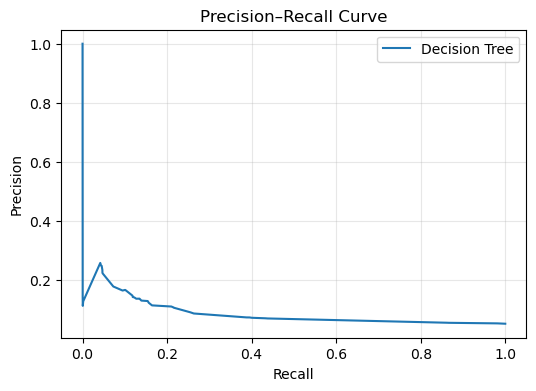

In [ ]:
def pr_curve(y_true_bin, y_pred, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=model_name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
pr_curve((y_true_count>0).astype(int), y_pred, "Decision Tree")

C:\Users\shere\AppData\Local\Temp\ipykernel_12952\987771759.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df.groupby("bucket").agg(


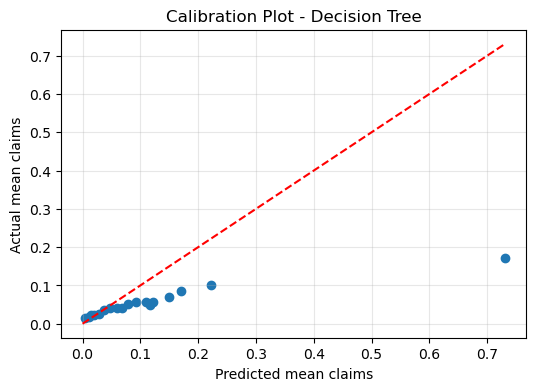

In [ ]:
def calibration_plot(y_true, y_pred, model_name, bins=20):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["bucket"] = pd.qcut(df["y_pred"], bins, duplicates='drop')
    
    calib = df.groupby("bucket").agg(
        predicted=("y_pred","mean"),
        actual=("y_true","mean")
    )

    plt.figure(figsize=(6,4))
    plt.scatter(calib["predicted"], calib["actual"], label=model_name)
    max_val = max(calib["predicted"].max(), calib["actual"].max())
    plt.plot([0, max_val], [0, max_val], "r--")
    plt.xlabel("Predicted mean claims")
    plt.ylabel("Actual mean claims")
    plt.title(f"Calibration Plot - {model_name}")
    plt.grid(alpha=0.3)
    plt.show()
calibration_plot(y_true_count, y_pred_count, "Decision Tree")

Want to also see what features were used most often in a decision tree

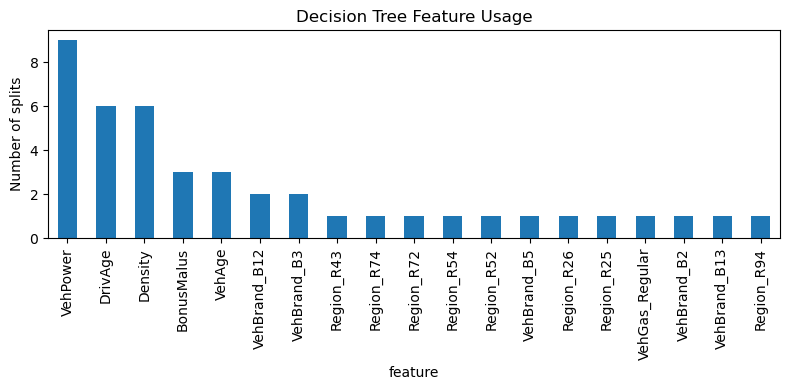

In [21]:
features_names=X_train.columns.tolist()


df_feat = pd.DataFrame({
    "feature": features_names,
    "count": [our_tree.feature_count[i] for i in range(len(features_names))]
})

df_feat = df_feat[df_feat["count"] > 0]

df_feat.sort_values("count", ascending=False).plot(
    kind="bar",
    x="feature",
    y="count",
    legend=False,
    figsize=(8,4),
    title="Decision Tree Feature Usage"
)

plt.ylabel("Number of splits")
plt.tight_layout()
plt.show()
                
        
